# test_graph.ipynb — LangGraph 챗봇 테스트

코어 로직은 `.py` 파일에 있고, 이 노트북은 **테스트 전용**.

| 셀 | 목적 |
|---|---|
| 0 | 환경 확인 (패키지 + Qdrant 연결) |
| 1 | 그래프 빌드 & Mermaid 시각화 |
| 2 | recommend 단독 |
| 3 | domain_qa 단독 |
| 4 | domain_qa + recommend 동시 (fan-out) |
| 5 | CLARIFY 멀티턴 흐름 |
| 6 | 연속 대화 (MemorySaver 확인) |
| 7 | 의도 분류 배치 정확도 (data/test.json) |
| 8 | 재랭킹 상세 확인 (Fallback A/B/C) |

## 0. 환경 확인

In [4]:
import sys
from pathlib import Path

HERE = Path(".").resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

# 패키지 확인
REQUIRED = ["langgraph", "langchain_core", "openai", "qdrant_client", "fastembed", "dotenv"]
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← 설치 필요")

if missing:
    raise SystemExit(f"pip install {' '.join(missing)}")
print()

  ✓ langgraph
  ✓ langchain_core
  ✓ openai
  ✓ qdrant_client
  ✓ fastembed
  ✓ dotenv



In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

print(f"OPENAI_API_KEY : {'설정됨' if os.getenv('OPENAI_API_KEY') else '없음 ← .env 확인 필요'}")

# Qdrant 연결 확인
from qdrant_client import QdrantClient
QDRANT_URL = os.getenv("QDRANT_URL", "http://localhost:6333")
try:
    _qc = QdrantClient(url=QDRANT_URL)
    cols = [c.name for c in _qc.get_collections().collections]
    print(f"Qdrant         : {QDRANT_URL}")
    print(f"컬렉션         : {cols}")
except Exception as e:
    print(f"Qdrant 연결 실패: {e}")

OPENAI_API_KEY : 설정됨
Qdrant         : http://localhost:6333
컬렉션         : ['domain_qna', 'breed_meta', 'products']


## 1. 그래프 빌드 & 시각화

In [6]:
from chatbot_graph import build_graph, chat

graph = build_graph()
print("그래프 빌드 완료")

그래프 빌드 완료


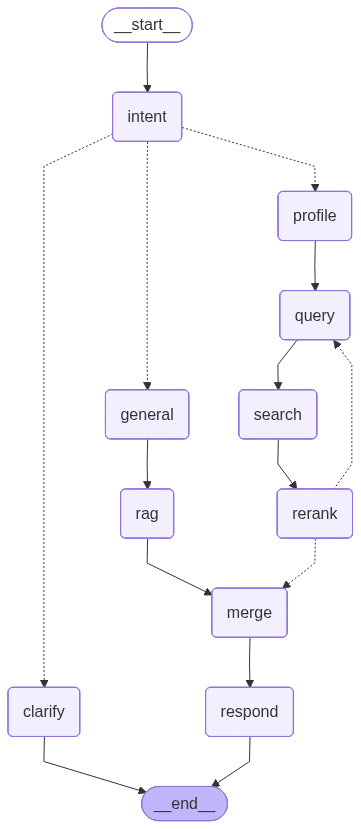

In [7]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## 2. recommend 단독

In [8]:
import uuid

r = chat(
    user_input="눈물 자국 심한 포메한테 먹일 사료 추천해줘",
    thread_id=str(uuid.uuid4()),
    pet_profile={"species": "dog", "breed": "포메라니안", "age": "3살"},
    health_concerns=["눈/눈물"],
)

print("=== 응답 ===")
print(r["response"])
print()
print(f"=== 상품 카드 ({len(r['product_cards'])}개) ===")
for c in r["product_cards"]:
    price = f"{c.get('discount_price'):,}원" if c.get('discount_price') else "-"
    print(f"  [{c.get('brand_name')}] {c.get('product_name')} | {price}")

[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': '강아지', 'category': '사료', 'subcategory': '눈/눈물', 'detected_aspect': None, 'budget': None}
Dense 모델 로드 중...


/Users/leemdo/Workspaces/SKN22-Final-2Team-WEB/notebooks/langgraph/utils.py:32: UserWarning: The model intfloat/multilingual-e5-large now uses mean pooling instead of CLS embedding. In order to preserve the previous behaviour, consider either pinning fastembed version to 0.5.1 or using `add_custom_model` functionality.
  _dense_model  = TextEmbedding("intfloat/multilingual-e5-large")


Sparse 모델 로드 중...
모델 로드 완료
[PROFILE] breed_meta 미검색: 포메라니안
[QUERY] query='눈물 자국 개선에 좋은 포메라니안 사료 추천', relaxation=0
[SEARCH] 20개 후보 (relaxation=0)
[RERANK] 최종 5개
[MERGE] mode=recommend | contexts=0, products=5
[RESPOND] 포메라니안은 눈물 자국이 생기기 쉬운 품종으로, 이는 종종 알레르기나 식이 요인과 관련이 있습니다. 눈물 자국을 줄이기 위해서는 항산화 성분이 ...
=== 응답 ===
포메라니안은 눈물 자국이 생기기 쉬운 품종으로, 이는 종종 알레르기나 식이 요인과 관련이 있습니다. 눈물 자국을 줄이기 위해서는 항산화 성분이 풍부한 사료를 선택하는 것이 좋습니다. 

추천드리는 사료는 '래핑찰리 독 기능성 사료 해피 포메라니안'입니다. 이 사료는 포메라니안의 건강을 고려하여 특별히 제조되었습니다. 추천 상품을 확인해 주세요!

=== 상품 카드 (5개) ===
  [래핑찰리] 래핑찰리 독 기능성 사료 굿 푸들 2kg | 22,000원
  [래핑찰리] 래핑찰리 독 기능성 사료 해피 포메라니안 2kg | 22,000원
  [위시본] 위시본 강아지 소고기 1.8kg | 32,000원
  [래핑찰리] 래핑찰리 독 기능성 사료 나이스 말티즈 2kg | 22,000원
  [위시본] 위시본 강아지 양고기 9kg | 120,000원


## 3. domain_qa 단독

In [9]:
r = chat(
    user_input="강아지한테 포도 먹이면 안 되는 이유가 뭐야?",
    thread_id=str(uuid.uuid4()),
    pet_profile={"species": "dog"},
)

print("=== 응답 ===")
print(r["response"])
print(f"\n상품 카드: {len(r['product_cards'])}개  (domain_qa 단독이면 0 예상)")

[INTENT] {'intents': ['domain_qa'], 'domain_intent': 'health_disease', 'pet_type': '강아지', 'category': None, 'subcategory': None, 'detected_aspect': None, 'budget': None}
[GENERAL] 정제 쿼리: 강아지에게 포도를 먹이면 안 되는 이유는 포도가 강아지에게 독성을 일으켜 신장 손상을 초래할 수 있기 때문입니다.
[RAG] 5개 컨텍스트 (domain_intent=health_disease)
[MERGE] mode=domain_qa | contexts=5, products=0
[RESPOND] 강아지에게 포도를 먹이면 안 되는 이유는 포도가 강아지에게 신장 손상을 일으킬 수 있기 때문입니다. 포도를 섭취한 강아지는 구토, 설사, 복통 ...
=== 응답 ===
강아지에게 포도를 먹이면 안 되는 이유는 포도가 강아지에게 신장 손상을 일으킬 수 있기 때문입니다. 포도를 섭취한 강아지는 구토, 설사, 복통 등의 증상을 보일 수 있으며, 심한 경우에는 신부전으로 이어질 수 있습니다. 따라서 강아지의 안전을 위해 포도는 절대 주지 않는 것이 좋습니다. 

강아지의 건강을 지키기 위한 다양한 간식과 영양제를 추천해 드립니다. 추천 상품을 확인해 주세요!

상품 카드: 0개  (domain_qa 단독이면 0 예상)


## 4. domain_qa + recommend 동시 (fan-out → MERGE)

In [10]:
r = chat(
    user_input="눈물 자국 왜 생겨? 좋은 사료도 알려줘",
    thread_id=str(uuid.uuid4()),
    pet_profile={"species": "dog", "breed": "비숑"},
)

print("=== 응답 ===")
print(r["response"])
print()
print(f"=== 상품 카드 ({len(r['product_cards'])}개) ===")
for c in r["product_cards"]:
    print(f"  - {c.get('product_name')}")

[INTENT] {'intents': ['domain_qa', 'recommend'], 'domain_intent': 'health_disease', 'pet_type': None, 'category': '사료', 'subcategory': None, 'detected_aspect': None, 'budget': None}
[PROFILE] breed_meta 미검색: 비숑
[GENERAL] 정제 쿼리: 비숑 강아지의 눈물 자국 원인과 이를 개선할 수 있는 좋은 사료 추천은 무엇인가요?
[RAG] 5개 컨텍스트 (domain_intent=health_disease)
[QUERY] query='비숑 강아지 눈물 자국 원인과 추천 사료 검색', relaxation=0
[MERGE] mode=domain_qa | contexts=5, products=0
[SEARCH] 20개 후보 (relaxation=0)
[RERANK] 최종 5개
[RESPOND] 비숑과 같은 강아지들은 눈물 자국이 생기기 쉬운데, 이는 눈물 속의 포르피린 성분이 공기와 만나 산화되어 갈색으로 변하기 때문입니다. 눈가를 자...
[MERGE] mode=combined | contexts=5, products=5
[RESPOND] 비숑 강아지의 눈물 자국은 눈물 속의 포르피린 성분이 공기와 만나 산화되어 발생합니다. 눈가를 자주 닦아주고, 알레르기를 유발할 수 있는 사료 ...
=== 응답 ===
비숑 강아지의 눈물 자국은 눈물 속의 포르피린 성분이 공기와 만나 산화되어 발생합니다. 눈가를 자주 닦아주고, 알레르기를 유발할 수 있는 사료 성분을 점검하는 것이 중요합니다. 또한, 눈 주변 피부가 붉어지거나 냄새가 나는 경우에는 세균 감염이 원인일 수 있으므로 주의가 필요합니다.

강아지에게 적합한 사료로는 로얄캐닌 비숑 프리제 전용 사료가 좋습니다. 추천 상품을 확인해 주세요!

=== 상품 카드 (5개) ===
  - 로얄캐닌 독 비숑 프리제 어덜트 1.5kg 요로건강
  - 래핑찰리 독 기능성 

## 5. CLARIFY 멀티턴 흐름

같은 `thread_id`로 재호출 → MemorySaver가 이전 상태 이어받음

In [11]:
TID = str(uuid.uuid4())

# 1턴: 의도 모호 → CLARIFY
r1 = chat(user_input="뭐 사야 해?", thread_id=TID)
print(f"[턴 1] → {r1['response']}")
print()

[INTENT] {'intents': ['unclear'], 'domain_intent': None, 'pet_type': None, 'category': None, 'subcategory': None, 'detected_aspect': None, 'budget': None}
[CLARIFY] count=1: 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!
[턴 1] → 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!



In [12]:
# 2턴: 반려동물 종류 답변
r2 = chat(user_input="강아지요", thread_id=TID)
print(f"[턴 2] → {r2['response']}")
print()

[INTENT] {'intents': ['unclear'], 'domain_intent': None, 'pet_type': '강아지', 'category': None, 'subcategory': None, 'detected_aspect': None, 'budget': None}
[CLARIFY] count=1: 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!
[턴 2] → 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!



In [13]:
# 3턴: 카테고리 답변 → recommend 실행
r3 = chat(user_input="사료 추천해줘", thread_id=TID)
print(f"[턴 3] → {r3['response']}")
print(f"상품 카드: {len(r3['product_cards'])}개")

[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': None, 'category': '사료', 'subcategory': None, 'detected_aspect': None, 'budget': None}
[PROFILE] 품종 정보 없음 — 스킵
[QUERY] query='"반려동물 사료 추천"', relaxation=0
[SEARCH] 20개 후보 (relaxation=0)
[RERANK] 최종 5개
[MERGE] mode=recommend | contexts=0, products=5
[RESPOND] 반려동물의 사료 선택은 나이, 건강 상태, 알레르기 등을 고려해야 합니다. 만약 나이가 많은 반려동물이라면, 더헬씨 시니어 가수분해 반건조 사료...
[턴 3] → 반려동물의 사료 선택은 나이, 건강 상태, 알레르기 등을 고려해야 합니다. 만약 나이가 많은 반려동물이라면, 더헬씨 시니어 가수분해 반건조 사료를 추천드립니다. 일반적인 반려동물에게는 더헬씨 밸런스 가수분해 반건조 사료가 좋습니다. 다양한 맛을 시도해보고 싶다면, 모노프로틴 사료 샘플도 좋은 선택이 될 수 있습니다. 추천 상품을 확인해 주세요!
상품 카드: 5개


## 6. 연속 대화 (MemorySaver — 컨텍스트 누적)

In [14]:
TID2 = str(uuid.uuid4())

turns = [
    ("고양이 유산균 추천해줘",             {"species": "cat", "age": "2살"}),
    ("방금 추천한 거 말고 다른 거 있어?",   None),
    ("그거 먹으면 설사가 나을 수 있어?",   None),
]

for i, (msg, profile) in enumerate(turns, 1):
    r = chat(user_input=msg, thread_id=TID2, pet_profile=profile)
    print(f"[턴 {i}] {msg}")
    print(f"  응답: {r['response'][:100]}...")
    print(f"  상품 카드: {len(r['product_cards'])}개")
    print()

[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': '고양이', 'category': '용품', 'subcategory': '영양/기능', 'detected_aspect': None, 'budget': None}
[PROFILE] 품종 정보 없음 — 스킵
[QUERY] query='2살 고양이 영양 유산균 추천 상품 검색', relaxation=0
[SEARCH] 15개 후보 (relaxation=0)
[RERANK] 최종 5개
[MERGE] mode=recommend | contexts=0, products=5
[RESPOND] 고양이에게 유산균은 소화 건강을 지원하고 면역력을 강화하는 데 도움을 줄 수 있습니다. 특히 2살의 고양이는 활발하고 건강한 성장을 위해 적절한...
[턴 1] 고양이 유산균 추천해줘
  응답: 고양이에게 유산균은 소화 건강을 지원하고 면역력을 강화하는 데 도움을 줄 수 있습니다. 특히 2살의 고양이는 활발하고 건강한 성장을 위해 적절한 영양이 필요하죠. 

추천 상품을 ...
  상품 카드: 5개

[INTENT] {'intents': ['unclear'], 'domain_intent': None, 'pet_type': None, 'category': None, 'subcategory': None, 'detected_aspect': None, 'budget': None}
[CLARIFY] count=1: 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!
[턴 2] 방금 추천한 거 말고 다른 거 있어?
  응답: 반려동물 상품 추천이나 건강 정보 상담을 도와드릴 수 있어요. 궁금한 점이 있으시면 말씀해 주세요!...
  상품 카드: 0개

[INTENT] {'intents': ['domain_qa'], 'domain_intent': 'health_disease', 'pet_type': None, 'categor

## 7. 의도 분류 배치 정확도 (data/test.json)

intent_node 단독 실행 — Qdrant 검색 없이 LLM 분류만 평가

In [15]:
import json
from collections import defaultdict
from nodes.intent import intent_node

with open("data/test.json", encoding="utf-8") as f:
    test_cases = json.load(f)

# test.json의 'smalltalk' → 시스템에서는 'unclear'
LABEL_MAP = {"smalltalk": "unclear", "recommend": "recommend",
             "domain_qa": "domain_qa", "unclear": "unclear"}

_DUMMY = {
    "messages": [], "pet_profile": None, "health_concerns": [],
    "allergies": [], "food_preferences": [], "user_id": None,
    "intents": [], "domain_intent": None, "clarification_count": 0,
    "detected_aspect": None, "budget": None, "search_query": None,
    "filters": None, "search_results": [], "reranked_results": [],
    "filter_relaxation_count": 0, "domain_contexts": [],
    "response": "", "product_cards": [],
}

correct = 0
errors  = []
by_class: dict[str, dict] = defaultdict(lambda: {"total": 0, "correct": 0})

for tc in test_cases:
    expected  = LABEL_MAP.get(tc["output"], tc["output"])
    result    = intent_node({**_DUMMY, "user_input": tc["input"]})
    detected  = result.get("intents") or ["unclear"]
    predicted = detected[0]

    by_class[expected]["total"] += 1
    if expected in detected:
        correct += 1
        by_class[expected]["correct"] += 1
    else:
        errors.append({"input": tc["input"], "expected": expected, "predicted": predicted})

total = len(test_cases)
print(f"전체 정확도: {correct}/{total} = {correct/total:.1%}\n")
for cls, v in sorted(by_class.items()):
    acc = v["correct"] / v["total"] if v["total"] else 0
    print(f"  {cls:15s}: {v['correct']:3d}/{v['total']:3d} = {acc:.1%}")

[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': '강아지', 'category': '사료', 'subcategory': '눈/눈물', 'detected_aspect': None, 'budget': None}
[INTENT] {'intents': ['domain_qa'], 'domain_intent': 'nutrition_diet', 'pet_type': '강아지', 'category': '용품', 'subcategory': None, 'detected_aspect': '관절', 'budget': None}
[INTENT] {'intents': ['domain_qa'], 'domain_intent': 'care_management', 'pet_type': '고양이', 'category': '모래', 'subcategory': '기타 모래', 'detected_aspect': '탈취제', 'budget': None}
[INTENT] {'intents': ['domain_qa'], 'domain_intent': 'nutrition_diet', 'pet_type': '강아지', 'category': '용품', 'subcategory': None, 'detected_aspect': '치매 예방', 'budget': None}
[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': '고양이', 'category': '용품', 'subcategory': '스크래쳐/캣타워', 'detected_aspect': '원목', 'budget': None}
[INTENT] {'intents': ['recommend'], 'domain_intent': None, 'pet_type': '강아지', 'category': '용품', 'subcategory': '목줄/하네스', 'detected_aspect': None, 'budget': No

In [16]:
# 오분류 케이스
print(f"오분류 {len(errors)}개:\n")
for e in errors:
    print(f"  expected={e['expected']:12s} | predicted={e['predicted']:12s}")
    print(f"  입력: {e['input']}")
    print()

오분류 4개:

  expected=recommend    | predicted=domain_qa   
  입력: 강아지 관절 영양제 중에 가루 타입 말고 츄어블 형태 있어?

  expected=recommend    | predicted=domain_qa   
  입력: 고양이 모래 탈취제 향기 좋은 거 뭐가 좋아?

  expected=recommend    | predicted=domain_qa   
  입력: 노령견 치매 예방에 도움 되는 보조제 알려줘

  expected=recommend    | predicted=unclear     
  입력: 고양이 유산균 중에 가루 안 날리는 캡슐형 있어?



## 8. 재랭킹 상세 확인 (Fallback A/B/C)

query/search/rerank 노드를 순서대로 단독 실행해 스코어 분포 확인

In [17]:
from nodes.recommend import query_node, search_node, rerank_node

_BASE = {
    "user_input":              "강아지 눈물 자국 사료",
    "messages":                [],
    "pet_profile":             {"species": "dog", "breed": "포메라니안"},
    "health_concerns":         ["눈/눈물"],
    "allergies":               [],
    "food_preferences":        [],
    "user_id":                 None,
    "intents":                 ["recommend"],
    "domain_intent":           None,
    "clarification_count":     0,
    "detected_aspect":         None,
    "budget":                  None,
    "filters":                 {"pet_type": "강아지", "category": "사료", "subcategory": "눈/눈물"},
    "search_results":          [],
    "reranked_results":        [],
    "filter_relaxation_count": 0,
    "domain_contexts":         [],
    "response":                "",
    "product_cards":           [],
}

q_out = query_node(_BASE)
s_out = search_node({**_BASE, **q_out})
r_out = rerank_node({**_BASE, **q_out, **s_out})

print(f"검색 후보: {len(s_out['search_results'])}개")
print(f"재랭킹 결과: {len(r_out['reranked_results'])}개")

[QUERY] query='포메라니안 눈물 자국 개선 사료', relaxation=0
[SEARCH] 20개 후보 (relaxation=0)
[RERANK] 최종 5개
검색 후보: 20개
재랭킹 결과: 5개


In [18]:
import pandas as pd

rows = []
for p in r_out["reranked_results"]:
    rows.append({
        "상품명":   (p.get("product_name") or "")[:28],
        "브랜드":   p.get("brand_name"),
        "가격":     p.get("discount_price"),
        "인기도":   round(p.get("popularity_score") or 0, 3),
        "감성평균": round(p.get("sentiment_avg")    or 0, 3),
        "재구매율": round(p.get("repeat_rate")      or 0, 3),
    })

pd.DataFrame(rows)

,상품명,브랜드,가격,인기도,감성평균,재구매율
0,래핑찰리 독 기능성 사료 굿 푸들 2kg,래핑찰리,22000,5.493,0.980,0
1,래핑찰리 독 기능성 사료 해피 포메라니안 2kg,래핑찰리,22000,0.000,0.000,0
2,위시본 강아지 소고기 1.8kg,위시본,32000,3.466,0.986,0
3,래핑찰리 독 기능성 사료 나이스 말티즈 2kg,래핑찰리,22000,3.466,0.914,0
4,위시본 강아지 양고기 9kg,위시본,120000,4.669,0.547,0


In [19]:
# Fallback 케이스 분포
candidates = s_out["search_results"]
case_a = [c for c in candidates if c.get("sentiment_avg") is not None and c.get("popularity_score") is not None]
case_b = [c for c in candidates if c.get("sentiment_avg") is None     and c.get("popularity_score") is not None]
case_c = [c for c in candidates if c.get("popularity_score") is None]

print(f"Case A (풀 스코어링):  {len(case_a):3d}개")
print(f"Case B (리뷰 없음):    {len(case_b):3d}개")
print(f"Case C (신상품):       {len(case_c):3d}개")

Case A (풀 스코어링):    4개
Case B (리뷰 없음):     16개
Case C (신상품):         0개
